#Luis David Pardo Pedraza

#Word importance-based Fake news detector

Fictional case study with real data. Main focus of this file is building a Word importance-based Fake news detector using traditional techniques for this type of tasks. In the second file of the carpet where this model is located, a second detector was constructed. This second one uses a completely different apporach for engaging with this task and the idea is to compare the results of both detectors. The comparative analysis of their results can be found in the README file found also within the same carpet.

##Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import re
import string
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luisd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

##Data collection

In [3]:
data1 = pd.read_csv(r"C:\Users\luisd\OneDrive\Desktop\Python_projects\Datasets\Datasets_News\Fake.csv")

In [4]:
data2 = pd.read_csv(r"C:\Users\luisd\OneDrive\Desktop\Python_projects\Datasets\Datasets_News\True.csv")

In [5]:
data2.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
data1["label"] = 1 #Fake news
data2["label"] = 0 #Real news

In [7]:
data = pd.concat([data1, data2], axis=0).reset_index(drop=True)

In [8]:
print("Shape of the Dataframe:", data.shape)
data.head()

Shape of the Dataframe: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


##Data cleaning and preprocessing

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


###Missing values

In [10]:
print("Number of missing values:")

data.isna().sum().sum()

Number of missing values:


0

###Duplicates

In [11]:
duplicates = data.duplicated()
duplicated_rows = data[duplicates]
print("Shape of the Dataframe of duplicated rows:", duplicated_rows.shape)

Shape of the Dataframe of duplicated rows: (209, 5)


In [12]:
#Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (44689, 5)


In [13]:
print("Remaining duplicate rows:", data.duplicated().sum())

Remaining duplicate rows: 0


###Remove unnecessary variables

In [14]:
data = data[['text', 'label']].copy()
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44689 non-null  object
 1   label   44689 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 698.4+ KB
None


##Split into train, validation and test sets

In [15]:
X_train_word, X_temp_word, y_train_word, y_temp_word = train_test_split(
    data["text"], data["label"], test_size=0.2, random_state=42, stratify=data["label"]
)
print(f"Training Set: {X_train_word.shape}, Temporary Set: {X_temp_word.shape}")

Training Set: (35751,), Temporary Set: (8938,)


In [16]:
X_val_word, X_test_word, y_val_word, y_test_word = train_test_split(
    X_temp_word, y_temp_word, test_size=0.5, random_state=42, stratify=y_temp_word
)
print(f"Final Dataset Sizes for Word importance-based Model:")
print(f"Training Set: {X_train_word.shape}")
print(f"Validation Set: {X_val_word.shape}")
print(f"Test Set: {X_test_word.shape}")

Final Dataset Sizes for Word importance-based Model:
Training Set: (35751,)
Validation Set: (4469,)
Test Set: (4469,)


##Feature Engineering

###Apply TF-IDF technique to vectorize text data

In [17]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_word)
X_val_tfidf = tfidf.transform(X_val_word)
X_test_tfidf = tfidf.transform(X_test_word)

###Dataset with word importance features

In [18]:
print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Validation TF-IDF shape: {X_val_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")

Training TF-IDF shape: (35751, 5000)
Validation TF-IDF shape: (4469, 5000)
Test TF-IDF shape: (4469, 5000)


##Model selection

###Considered algorythms

In [19]:
#Models to try
models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", C=100),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
}

In [20]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train_word, cv=5, scoring="f1")
    cv_results[name] = scores.mean()
    print(f"{name}: F1-score = {scores.mean():.4f}")

sorted_results = sorted(cv_results.items(), key=lambda x: x[1], reverse=True)
print("\nModel Performance Comparison (F1-score):")
for model, score in sorted_results:
    print(f"{model}: {score:.4f}")

Logistic Regression: F1-score = 0.9944
Random Forest: F1-score = 0.9974
XGBoost: F1-score = 0.9975

Model Performance Comparison (F1-score):
XGBoost: 0.9975
Random Forest: 0.9974
Logistic Regression: 0.9944


##Hyperparameter tuning and cross validation using Randomized Search CV

In [21]:
param_dist = { #Hyperparameter search space
    'n_estimators': [100, 300, 500],  #Number of trees
    'learning_rate': [0.01, 0.1, 0.2],  #Step size
    'max_depth': [3, 6, 9],  #Depth of each tree
    'subsample': [0.7, 0.8, 1.0],  #Percentage of data used per tree
    'colsample_bytree': [0.7, 0.8, 1.0],  #Percentage of features used per tree
    'gamma': [0, 0.1, 0.2],  #Minimum loss reduction
    'lambda': [1, 2, 3]  #L2 regularization
}

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

#Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist, n_iter=20, 
    scoring='f1', cv=5, verbose=2, random_state=42, n_jobs=-1
)

random_search.fit(X_train_tfidf, y_train_word)
print(f"Best Hyperparameters: {random_search.best_params_}")
best_word_xgb = random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'lambda': 1, 'gamma': 0, 'colsample_bytree': 0.8}


##Training and evaluation

###Training the best XG Boost model

In [23]:
best_word_xgb = xgb.XGBClassifier(
    use_label_encoder=False, eval_metric="logloss",
    subsample=0.8, n_estimators=300, max_depth=6,
    learning_rate=0.1, reg_lambda=1, gamma=0, colsample_bytree=0.8,
    random_state=42
)
best_word_xgb.fit(X_train_tfidf, y_train_word)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, eval_metric='logloss', gamma=0,
              gpu_id=-1, importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=12, num_parallel_tree=1,
              predictor='auto', random_state=42, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=0.8, tree_method='exact',
              use_label_encoder=False, validate_parameters=1, verbosity=None)

###Evaluate on validation set

In [24]:
y_val_pred_xgb_tuned = best_word_xgb.predict(X_val_tfidf)

In [25]:
accuracy_val = accuracy_score(y_val_word, y_val_pred_xgb_tuned)
precision_val = precision_score(y_val_word, y_val_pred_xgb_tuned)
recall_val = recall_score(y_val_word, y_val_pred_xgb_tuned)
f1_val = f1_score(y_val_word, y_val_pred_xgb_tuned)

print(f"\nTuned Word importance-based Model (XGBoost) Performance on Validation Set:")
print(f"Accuracy:  {accuracy_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1-score:  {f1_val:.4f}")


Tuned Word importance-based Model (XGBoost) Performance on Validation Set:
Accuracy:  0.9984
Precision: 0.9987
Recall:    0.9983
F1-score:  0.9985


###Evaluate on test set

In [26]:
y_test_pred_xgb_tuned = best_word_xgb.predict(X_test_tfidf)

In [27]:
accuracy = accuracy_score(y_test_word, y_test_pred_xgb_tuned)
precision = precision_score(y_test_word, y_test_pred_xgb_tuned)
recall = recall_score(y_test_word, y_test_pred_xgb_tuned)
f1 = f1_score(y_test_word, y_test_pred_xgb_tuned)

print(f"\nFinal Tuned Word importance-based Model (XGBoost) Performance on Test Set:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Final Tuned Word importance-based Model (XGBoost) Performance on Test Set:
Accuracy:  0.9984
Precision: 0.9987
Recall:    0.9983
F1-score:  0.9985


###Calssification Report

In [29]:
y_test_pred_word = best_word_xgb.predict(X_test_tfidf)

In [30]:
print("\nWord importance-based Model (XGBoost) - Classification Report:")
print(classification_report(y_test_word, y_test_pred_word))


Word importance-based Model (XGBoost) - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2121
           1       1.00      1.00      1.00      2348

    accuracy                           1.00      4469
   macro avg       1.00      1.00      1.00      4469
weighted avg       1.00      1.00      1.00      4469



###Confusion matrix

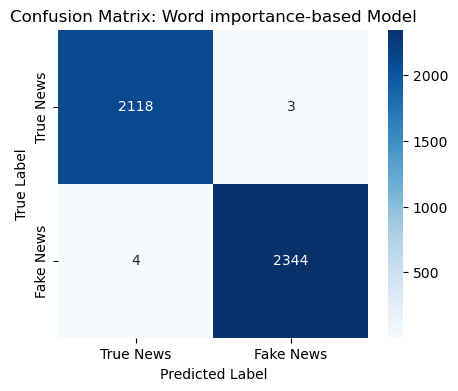

In [32]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["True News", "Fake News"], yticklabels=["True News", "Fake News"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

plot_confusion_matrix(y_test_word, y_test_pred_word, "Word importance-based Model")